## Bibliotekos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score

from sklearn.manifold import TSNE

## Metrikos

In [2]:
def clustering_metrics_fun(data, labels, true_labels, results):
    db_index = davies_bouldin_score(data, labels)
    sil_score = silhouette_score(data, labels)
    ch_index = calinski_harabasz_score(data, labels)
    ari_score = adjusted_rand_score(true_labels, labels)

    results.append({
        "Kategorija": names[i],
        "Davies-Bouldin": round(db_index, 2),
        "Silhouette": round(sil_score, 2),
        "Calinski-Harabasz": round(ch_index, 2),
        "ARI": round(ari_score, 2)
    })

## Klasterizavimo stabilumo testavimas

In [3]:
def clustering_stability(N, data, true_labels, k):
    clustering_labels = []
    indices = []

    for i in range(N):
        sample = data.sample(frac=0.8)
        kmeans = KMeans(n_clusters=k, n_init='auto')
        labels = kmeans.fit_predict(sample)

        clustering_labels.append(labels)
        indices.append(sample.index)

    ari_scores = []

    for i in range(N):
        for j in range(i + 1, N):
            
            common_index = indices[i].intersection(indices[j])
            
            if len(common_index) > 0:
                labels_i = pd.Series(clustering_labels[i], index=indices[i]).loc[common_index]
                labels_j = pd.Series(clustering_labels[j], index=indices[j]).loc[common_index]
                
                ari = adjusted_rand_score(labels_i, labels_j)
                ari_scores.append(ari)

    mean_ari = np.mean(ari_scores)
    std_ari = np.std(ari_scores)
    cv_ari = (std_ari / mean_ari) if mean_ari != 0 else 0
    
    print(f"Vidutinis klasterių stabilumas (ARI): {np.mean(ari_scores):.3f}")
    print(f"Stabilumo standartinis nuokrypis: {np.std(ari_scores):.3f}")
    print(f"Variacijos koeficientas: {cv_ari:.3f}")


## Duomenys - visi rinkinio požymiai

In [4]:
min_max_data = pd.read_csv('full_min_max_data.csv')
min_max_data.head(5)

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc,credit.policy,purpose,not.fully.paid
0,0.088433,0.404762,0.252568,0.006169,0.901408,0.000000,0.0,0.0,0.015173,0,all_other,0
1,0.034633,0.285714,0.199361,0.009275,0.413146,0.148148,0.0,0.0,0.049939,0,all_other,1
2,0.504371,0.214286,0.000000,0.000000,0.448826,0.037037,0.0,0.0,0.000344,0,all_other,0
3,0.336247,0.333333,0.218260,0.000000,0.203756,0.148148,0.0,0.0,0.086767,0,all_other,0
4,0.187962,0.547619,0.408971,0.011692,0.646948,0.222222,0.0,0.0,0.050030,0,all_other,0


In [5]:
print(min_max_data.dtypes)

dti                  float64
fico                 float64
days.with.cr.line    float64
revol.bal            float64
revol.util           float64
inq.last.6mths       float64
delinq.2yrs          float64
pub.rec              float64
annual.inc           float64
credit.policy          int64
purpose               object
not.fully.paid         int64
dtype: object


In [6]:
cols_to_factor = ['credit.policy', 'not.fully.paid', 'purpose']
for col in cols_to_factor:
    min_max_data[col] = min_max_data[col].astype('category')
print(min_max_data.dtypes)

dti                   float64
fico                  float64
days.with.cr.line     float64
revol.bal             float64
revol.util            float64
inq.last.6mths        float64
delinq.2yrs           float64
pub.rec               float64
annual.inc            float64
credit.policy        category
purpose              category
not.fully.paid       category
dtype: object


Išskiriame paskolos paskirties grupes

In [7]:
min_max_debt_consolidation = min_max_data[min_max_data['purpose'] == 'debt_consolidation']
min_max_credit_card = min_max_data[min_max_data['purpose'] == 'credit_card']
min_max_home_improvement = min_max_data[min_max_data['purpose'] == 'home_improvement']

Kiekvienam rinkiniui pritaikome t-SNE

In [8]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)
tsne_debt_consolidation = tsne.fit_transform(min_max_debt_consolidation.select_dtypes(include=[np.number]))
tsne_credit_card = tsne.fit_transform(min_max_credit_card.select_dtypes(include=[np.number]))
tsne_home_improvement = tsne.fit_transform(min_max_home_improvement.select_dtypes(include=[np.number]))

## Klasterizavimas ant orginalių duomenų

### Klasterių skaičiaus nustatymas

#### Empyrinis metodas

In [9]:
print('Klasterių skaičius skolų konsolidavimo grupėje: ', round(np.sqrt(len(min_max_debt_consolidation)/2)))
print('Klasterių skaičius kredito kortelės grupėje: ', round(np.sqrt(len(min_max_credit_card)/2)))
print('Klasterių skaičius namų remonto grupėje: ', round(np.sqrt(len(min_max_home_improvement)/2)))

Klasterių skaičius skolų konsolidavimo grupėje:  28
Klasterių skaičius kredito kortelės grupėje:  16
Klasterių skaičius namų remonto grupėje:  11


In [10]:
min_max_debt_consolidation.head()

,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,annual.inc,credit.policy,purpose,not.fully.paid
1437,0.887693,0.380952,0.209670,0.013196,0.388732,0.074074,0.000000,0.0,0.020476,0,debt_consolidation,0
1438,0.437794,0.333333,0.111737,0.024302,0.312676,0.148148,0.000000,0.0,0.016794,0,debt_consolidation,1
1439,0.656355,0.261905,0.249184,0.021710,0.311737,0.148148,0.166667,0.0,0.017039,0,debt_consolidation,0
1440,0.544385,0.261905,0.353991,0.014127,0.781221,0.148148,0.000000,0.0,0.028333,0,debt_consolidation,0
1441,0.891728,0.238095,0.142833,0.054771,0.615023,0.148148,0.000000,0.0,0.025485,0,debt_consolidation,0


#### Alkūnės metodas ir Vidutinio silueto metodas

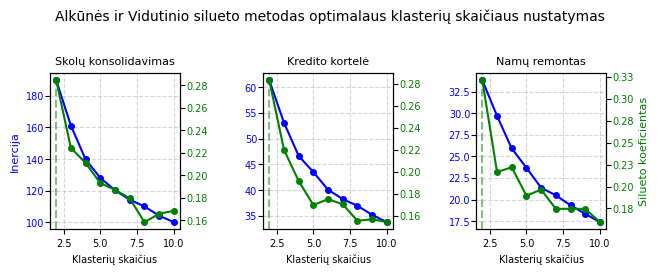

In [11]:
subsets = {
    "Skolų konsolidavimas": min_max_debt_consolidation.select_dtypes(include=[np.number]),
    "Kredito kortelė": min_max_credit_card.select_dtypes(include=[np.number]),
    "Namų remontas": min_max_home_improvement.select_dtypes(include=[np.number])
}

width_inch = 17 / 2.54
height_inch = width_inch * 0.4

fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

for i, (name, data) in enumerate(subsets.items()):
    inertias = []
    all_silhouette_avg = []
    k_range = range(2, 11)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=2026, n_init='auto')
        cluster_labels = kmeans.fit_predict(data)
        
        inertias.append(kmeans.inertia_)
        all_silhouette_avg.append(silhouette_score(data, cluster_labels))

    best_k = k_range[np.argmax(all_silhouette_avg)]

    ax1 = axes[i]
    ax1.plot(k_range, inertias, 'bo-', label='Inertia', markersize=4)
    ax1.set_xlabel('Klasterių skaičius', fontsize=7)
    ax1.tick_params(axis='x', labelsize=7)
    if name == 'Skolų konsolidavimas':
        ax1.set_ylabel('Inercija', color='b', fontsize=8)
    else:
        ax1.set_ylabel('', color='b')
    ax1.tick_params(axis='y', labelsize=7, labelcolor='b', pad=1)
    ax1.set_title(f'{name}', fontsize=8)
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(k_range, all_silhouette_avg, 'go-', label='Siluetas', markersize=4)
    ax2.yaxis.set_major_formatter('{x:.2f}')
    if name == 'Namų remontas':
        ax2.set_ylabel('Silueto koeficientas', color='g', fontsize=8)
    else:
        ax2.set_ylabel('', color='g')
    ax2.tick_params(axis='y', labelsize=7, labelcolor='g', pad=1)
    
    ax2.axvline(x=best_k, color="g", linestyle="--", alpha=0.5)

plt.suptitle('Alkūnės ir Vidutinio silueto metodas optimalaus klasterių skaičiaus nustatymas', fontsize=10, y=1.01)

plt.tight_layout(w_pad=2)
plt.savefig("clusters_1.png", dpi=300, bbox_inches='tight')

plt.show()


In [12]:
names = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]

data_subsets = [
    min_max_debt_consolidation.select_dtypes(include=[np.number]),
    min_max_credit_card.select_dtypes(include=[np.number]),
    min_max_home_improvement.select_dtypes(include=[np.number])]

data_labels = [
    min_max_debt_consolidation['credit.policy'],
    min_max_credit_card['credit.policy'],
    min_max_home_improvement['credit.policy']]
    
tsne_results = [tsne_debt_consolidation, tsne_credit_card, tsne_home_improvement]

Išsaugota: clustered_original_full_debt_consolidation.csv
Išsaugota: clustered_original_full_credit_card.csv
Išsaugota: clustered_original_full_home_improvement.csv


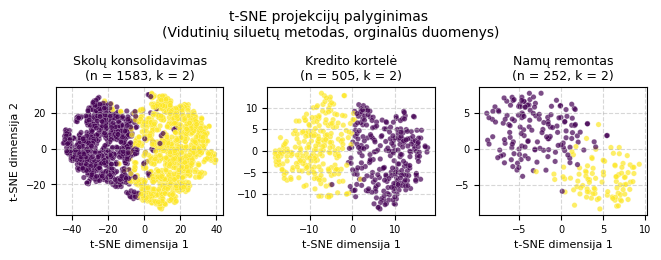

In [13]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.4 

clustering_metrics = []
export_names = ["clustered_original_full_debt_consolidation.csv", "clustered_original_full_credit_card.csv", "clustered_original_full_home_improvement.csv"]
fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

original_data_1_labels = []

for i in range(3):
    kmeans = KMeans(n_clusters=2, random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(data_subsets[i])

    clustering_metrics_fun(data_subsets[i], labels, data_labels[i], clustering_metrics)
    original_data_1_labels.append(labels)

    data_subsets[i]['cluster'] = labels
    data_subsets[i].to_csv(export_names[i], index=False)
    print(f"Išsaugota: {export_names[i]}") 

    
    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], c=labels, cmap='viridis', alpha=0.7, s=15, edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = 2)', fontsize=9)
    ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
    if i == 0:
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle( 't-SNE projekcijų palyginimas \n(Vidutinių siluetų metodas, orginalūs duomenys)',fontsize=10, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig("all_original_data_1.png", dpi=300, bbox_inches='tight')

plt.show()

In [14]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            1.37        0.28             740.63 -0.00
1       Kredito kortelė            1.36        0.28             236.37  0.01
2         Namų remontas            1.25        0.32             136.19  0.10


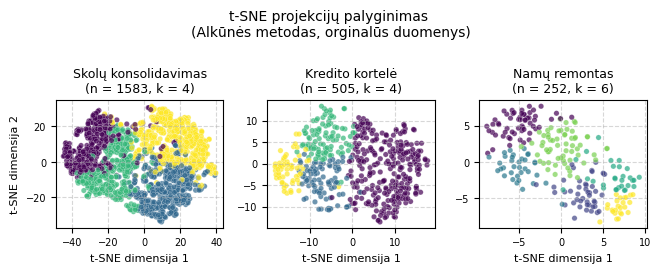

In [15]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.4

clustering_metrics = []
k = [4, 4, 6]

fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

original_data_2_labels = []

for i in range(3):
    kmeans = KMeans(n_clusters=k[i], random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(data_subsets[i])

    clustering_metrics_fun(data_subsets[i], labels, data_labels[i], clustering_metrics)
    original_data_2_labels.append(labels)

    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], c=labels, cmap='viridis', alpha=0.7, s=15, edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = {k[i]})', fontsize=9)
    ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
    if i == 0:
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle('t-SNE projekcijų palyginimas \n(Alkūnės metodas, orginalūs duomenys)', fontsize=10, y=1)

plt.tight_layout(pad=1.0)
plt.savefig("all_original_data_2.png", dpi=300, bbox_inches='tight')

plt.show()

In [16]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            1.75        0.21            1873.04 -0.00
1       Kredito kortelė            1.33        0.41             538.82 -0.04
2         Namų remontas            1.46        0.22             207.36  0.03


## Klasterizavimas ant sumažintos dimensijos

### Klasterių skaičiaus nustatymas

#### Empyrinis metodas

In [17]:
print('Klasterių skaičius skolų konsolidavimo grupėje: ', round(np.sqrt(len(tsne_debt_consolidation)/2)))
print('Klasterių skaičius kredito kortelės grupėje: ', round(np.sqrt(len(tsne_credit_card)/2)))
print('Klasterių skaičius namų remonto grupėje: ', round(np.sqrt(len(tsne_home_improvement)/2)))

Klasterių skaičius skolų konsolidavimo grupėje:  28
Klasterių skaičius kredito kortelės grupėje:  16
Klasterių skaičius namų remonto grupėje:  11


#### Alkūnės metodas ir Vidutinio silueto metodas

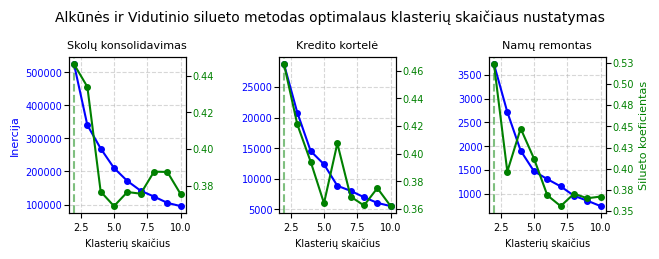

In [18]:
subsets = {
    "Skolų konsolidavimas": tsne_debt_consolidation,
    "Kredito kortelė": tsne_credit_card,
    "Namų remontas": tsne_home_improvement
}

width_inch = 17 / 2.54
height_inch = width_inch * 0.4

fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

for i, (name, data) in enumerate(subsets.items()):
    inertias = []
    all_silhouette_avg = []
    k_range = range(2, 11)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=2026, n_init='auto')
        cluster_labels = kmeans.fit_predict(data)
        
        inertias.append(kmeans.inertia_)
        all_silhouette_avg.append(silhouette_score(data, cluster_labels))

    best_k = k_range[np.argmax(all_silhouette_avg)]

    ax1 = axes[i]
    ax1.plot(k_range, inertias, 'bo-', label='Inertia', markersize=4)
    ax1.set_xlabel('Klasterių skaičius', fontsize=7)
    ax1.tick_params(axis='x', labelsize=7)
    if name == 'Skolų konsolidavimas':
        ax1.set_ylabel('Inercija', color='b', fontsize=8)
    else:
        ax1.set_ylabel('', color='b')
    ax1.tick_params(axis='y', labelsize=7, labelcolor='b', pad=1)
    ax1.set_title(f'{name}', fontsize=8)
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(k_range, all_silhouette_avg, 'go-', label='Siluetas', markersize=4)
    ax2.yaxis.set_major_formatter('{x:.2f}')
    if name == 'Namų remontas':
        ax2.set_ylabel('Silueto koeficientas', color='g', fontsize=8)
    else:
        ax2.set_ylabel('', color='g')
    ax2.tick_params(axis='y', labelsize=7, labelcolor='g', pad=1)
    
    ax2.axvline(x=best_k, color="g", linestyle="--", alpha=0.5)

plt.suptitle('Alkūnės ir Vidutinio silueto metodas optimalaus klasterių skaičiaus nustatymas', fontsize=10, y=0.95)

plt.tight_layout(w_pad=2)
plt.savefig("clusters_2.png", dpi=300, bbox_inches='tight')

plt.show()


In [19]:
names = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]
tsne_results = [tsne_debt_consolidation, tsne_credit_card, tsne_home_improvement]

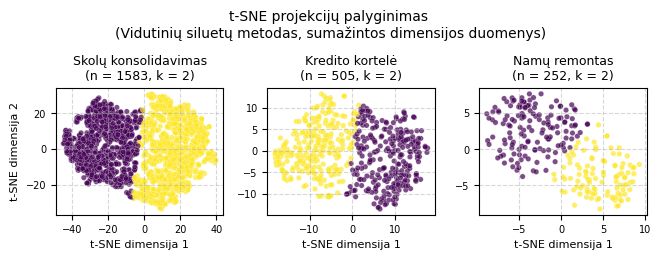

In [20]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.4 

clustering_metrics = []
fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

tsne_data_1_labels = []

for i in range(3):
    kmeans = KMeans(n_clusters=2, random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(tsne_results[i])

    clustering_metrics_fun(tsne_results[i], labels, data_labels[i], clustering_metrics)
    tsne_data_1_labels.append(labels)
    
    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], c=labels, cmap='viridis', alpha=0.7, s=15, edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = 2)', fontsize=9)
    ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
    if i == 0:
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle( 't-SNE projekcijų palyginimas \n(Vidutinių siluetų metodas, sumažintos dimensijos duomenys)',fontsize=10, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig("all_tsne_1.png", dpi=300, bbox_inches='tight')

plt.show()

In [21]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            0.89        0.45            1676.04  0.00
1       Kredito kortelė            0.83        0.46             619.31  0.02
2         Namų remontas            0.69        0.52             437.46  0.07


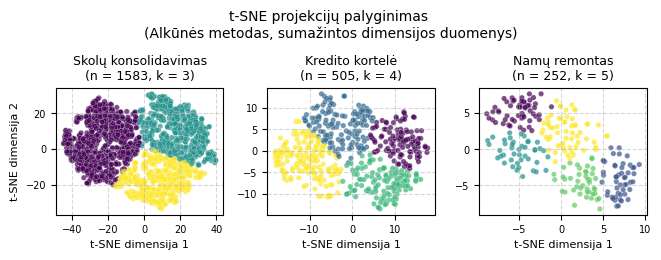

In [22]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.4 

clustering_metrics = []
k = [3, 4, 5]
fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

tsne_data_2_labels = []

for i in range(3):
    kmeans = KMeans(n_clusters=k[i], random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(tsne_results[i])

    clustering_metrics_fun(tsne_results[i], labels, data_labels[i], clustering_metrics)
    tsne_data_2_labels.append(labels)
    
    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], c=labels, cmap='viridis', alpha=0.7, s=15, edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = {k[i]})', fontsize=9)
    ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
    if i == 0:
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle( 't-SNE projekcijų palyginimas \n(Alkūnės metodas, sumažintos dimensijos duomenys)',fontsize=10, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig("all_tsne_2.png", dpi=300, bbox_inches='tight')

plt.show()

In [23]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            0.82        0.43            1719.34  0.03
1       Kredito kortelė            0.90        0.39             569.66  0.03
2         Namų remontas            0.82        0.41             366.67  0.02


Stabilumas prieš ir po dimensijų mažinimo

In [24]:
names = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]
for i in range(3):
    if i == 0:
        print(f"-----Klasterių stabilumas (vidutinio silueto metodas)-----")
    print(f"{names[i]}: {adjusted_rand_score(original_data_1_labels[i], tsne_data_1_labels[i])}")

for i in range(3):
    if i == 0:
        print(f"-----Klasterių stabilumas (alkūnės metodas)-----")
    print(f"{names[i]}: {adjusted_rand_score(original_data_2_labels[i], tsne_data_2_labels[i])}")

-----Klasterių stabilumas (vidutinio silueto metodas)-----
Skolų konsolidavimas: 0.8011263725660592
Kredito kortelė: 0.8844884669899532
Namų remontas: 0.8177023476485237
-----Klasterių stabilumas (alkūnės metodas)-----
Skolų konsolidavimas: 0.5396933203763854
Kredito kortelė: 0.3186924058885455
Namų remontas: 0.6682668927012471


## Atrinktų požymių tyrimas

## RFE

In [25]:
rfecv_debt_consolidation_data = pd.read_csv('rfecv_debt_consolidation.csv')
rfecv_credit_card_data = pd.read_csv('rfecv_credit_card.csv')
rfecv_home_improvement_data = pd.read_csv('rfecv_home_improvement.csv')

In [26]:
datasets = [rfecv_debt_consolidation_data, rfecv_credit_card_data, rfecv_home_improvement_data]
for data in datasets:
    data['credit.policy'] = data['credit.policy'].astype('category')

print(rfecv_debt_consolidation_data.dtypes)

dti                   float64
fico                  float64
days.with.cr.line     float64
revol.bal             float64
revol.util            float64
inq.last.6mths        float64
pub.rec               float64
annual.inc            float64
credit.policy        category
dtype: object


In [27]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)
tsne_rfecv_debt_consolidation_data = tsne.fit_transform(rfecv_debt_consolidation_data.select_dtypes(include=[np.number]))
tsne_rfecv_home_improvement_data = tsne.fit_transform(rfecv_home_improvement_data.select_dtypes(include=[np.number]))

### Klasterizavimas ant orginalių duomenų

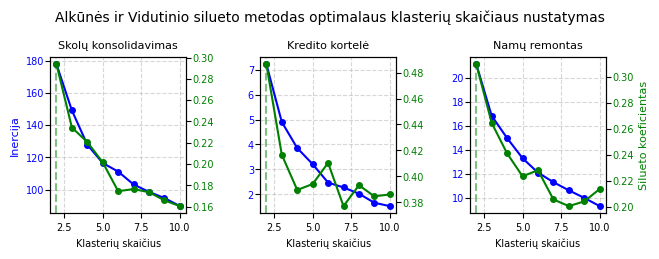

In [28]:
subsets = {
    "Skolų konsolidavimas": rfecv_debt_consolidation_data.select_dtypes(include=[np.number]),
    "Kredito kortelė": rfecv_credit_card_data.select_dtypes(include=[np.number]),
    "Namų remontas": rfecv_home_improvement_data.select_dtypes(include=[np.number])
}

width_inch = 17 / 2.54
height_inch = width_inch * 0.4

fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

for i, (name, data) in enumerate(subsets.items()):
    inertias = []
    all_silhouette_avg = []
    k_range = range(2, 11)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=2026, n_init='auto')
        cluster_labels = kmeans.fit_predict(data)
        
        inertias.append(kmeans.inertia_)
        all_silhouette_avg.append(silhouette_score(data, cluster_labels))

    best_k = k_range[np.argmax(all_silhouette_avg)]

    ax1 = axes[i]
    ax1.plot(k_range, inertias, 'bo-', label='Inertia', markersize=4)
    ax1.set_xlabel('Klasterių skaičius', fontsize=7)
    ax1.tick_params(axis='x', labelsize=7)
    if name == 'Skolų konsolidavimas':
        ax1.set_ylabel('Inercija', color='b', fontsize=8)
    else:
        ax1.set_ylabel('', color='b')
    ax1.tick_params(axis='y', labelsize=7, labelcolor='b', pad=1)
    ax1.set_title(f'{name}', fontsize=8)
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(k_range, all_silhouette_avg, 'go-', label='Siluetas', markersize=4)
    ax2.yaxis.set_major_formatter('{x:.2f}')
    if name == 'Namų remontas':
        ax2.set_ylabel('Silueto koeficientas', color='g', fontsize=8)
    else:
        ax2.set_ylabel('', color='g')
    ax2.tick_params(axis='y', labelsize=7, labelcolor='g', pad=1)
    
    ax2.axvline(x=best_k, color="g", linestyle="--", alpha=0.5)

plt.suptitle('Alkūnės ir Vidutinio silueto metodas optimalaus klasterių skaičiaus nustatymas', fontsize=10, y=0.95)

plt.tight_layout(w_pad=2)
plt.savefig("clusters_3.png", dpi=300, bbox_inches='tight')

plt.show()


In [29]:
names = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]
data_subsets = [
    rfecv_debt_consolidation_data.select_dtypes(include=[np.number]),
    rfecv_credit_card_data.select_dtypes(include=[np.number]),
    rfecv_home_improvement_data.select_dtypes(include=[np.number])]
data_labels = [
    rfecv_debt_consolidation_data['credit.policy'],
    rfecv_credit_card_data['credit.policy'],
    rfecv_home_improvement_data['credit.policy']]
tsne_results = [tsne_rfecv_debt_consolidation_data, rfecv_credit_card_data.select_dtypes(include=[np.number]).to_numpy(), tsne_rfecv_home_improvement_data]

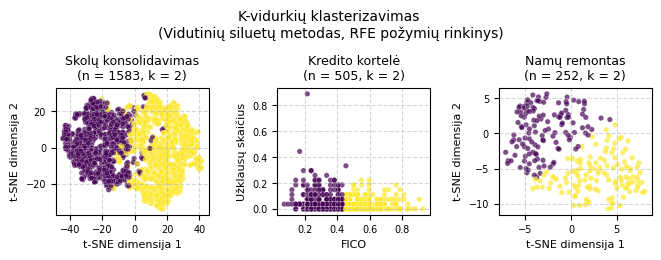

In [30]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.40 

clustering_metrics = []

fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

for i in range(3):
    kmeans = KMeans(n_clusters=2, random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(data_subsets[i])

    clustering_metrics_fun(data_subsets[i], labels, data_labels[i], clustering_metrics)
    
    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], 
                         c=labels, cmap='viridis', alpha=0.7, s=15, 
                         edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = 2)', fontsize=9)

    if names[i] == "Kredito kortelė":
        ax.set_xlabel('FICO', fontsize=8)
        ax.set_ylabel('Užklausų skaičius', fontsize=8)
    else:
        ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
            
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle('K-vidurkių klasterizavimas \n(Vidutinių siluetų metodas, RFE požymių rinkinys)', fontsize=10, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig("rfe_original_data_1.png", dpi=300, bbox_inches='tight')

plt.show()

In [31]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            1.32        0.29             790.57 -0.00
1       Kredito kortelė            0.74        0.49             655.47  0.05
2         Namų remontas            1.25        0.31             134.58  0.06


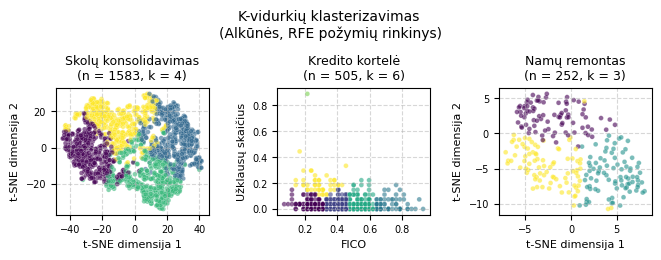

In [32]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.40 

clustering_metrics = []
k = [4, 6, 3]

fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

for i in range(3):
    kmeans = KMeans(n_clusters=k[i], random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(data_subsets[i])

    clustering_metrics_fun(data_subsets[i], labels, data_labels[i], clustering_metrics)
    
    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], 
                         c=labels, cmap='viridis', alpha=0.6, s=12, 
                         edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = {k[i]})', fontsize=9)

    if names[i] == "Kredito kortelė":
        ax.set_xlabel('FICO', fontsize=8)
        ax.set_ylabel('Užklausų skaičius', fontsize=8)
    else:
        ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
            
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle('K-vidurkių klasterizavimas \n(Alkūnės, RFE požymių rinkinys)', fontsize=10, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig("rfe_original_data_2.png", dpi=300, bbox_inches='tight')

plt.show()

In [33]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            1.41        0.22             571.60  0.00
1       Kredito kortelė            0.70        0.41             571.00  0.09
2         Namų remontas            1.26        0.26             116.21  0.03


### Klasterizavimas ant sumažintos dimensijos

In [34]:
rfecv_credit_card_data.head()

,fico,inq.last.6mths,credit.policy
0,0.285714,0.185185,0
1,0.142857,0.000000,0
2,0.523810,0.000000,0
3,0.190476,0.111111,0
4,0.404762,0.148148,0


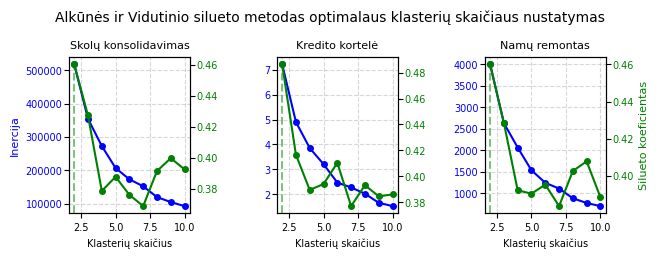

In [35]:
subsets = {
    "Skolų konsolidavimas": tsne_rfecv_debt_consolidation_data,
    "Kredito kortelė": rfecv_credit_card_data.select_dtypes(include=[np.number]).to_numpy(),
    "Namų remontas": tsne_rfecv_home_improvement_data
}

width_inch = 17 / 2.54
height_inch = width_inch * 0.4

fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

for i, (name, data) in enumerate(subsets.items()):
    inertias = []
    all_silhouette_avg = []
    k_range = range(2, 11)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=2026, n_init='auto')
        cluster_labels = kmeans.fit_predict(data)
        
        inertias.append(kmeans.inertia_)
        all_silhouette_avg.append(silhouette_score(data, cluster_labels))

    best_k = k_range[np.argmax(all_silhouette_avg)]

    ax1 = axes[i]
    ax1.plot(k_range, inertias, 'bo-', label='Inertia', markersize=4)
    ax1.set_xlabel('Klasterių skaičius', fontsize=7)
    ax1.tick_params(axis='x', labelsize=7)
    if name == 'Skolų konsolidavimas':
        ax1.set_ylabel('Inercija', color='b', fontsize=8)
    else:
        ax1.set_ylabel('', color='b')
    ax1.tick_params(axis='y', labelsize=7, labelcolor='b', pad=1)
    ax1.set_title(f'{name}', fontsize=8)
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(k_range, all_silhouette_avg, 'go-', label='Siluetas', markersize=4)
    ax2.yaxis.set_major_formatter('{x:.2f}')
    if name == 'Namų remontas':
        ax2.set_ylabel('Silueto koeficientas', color='g', fontsize=8)
    else:
        ax2.set_ylabel('', color='g')
    ax2.tick_params(axis='y', labelsize=7, labelcolor='g', pad=1)
    
    ax2.axvline(x=best_k, color="g", linestyle="--", alpha=0.5)

plt.suptitle('Alkūnės ir Vidutinio silueto metodas optimalaus klasterių skaičiaus nustatymas', fontsize=10, y=0.95)

plt.tight_layout(w_pad=2)
plt.savefig("clusters_4.png", dpi=300, bbox_inches='tight')

plt.show()


In [36]:
names = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]
tsne_results = [tsne_rfecv_debt_consolidation_data, rfecv_credit_card_data.select_dtypes(include=[np.number]).to_numpy(), tsne_rfecv_home_improvement_data]

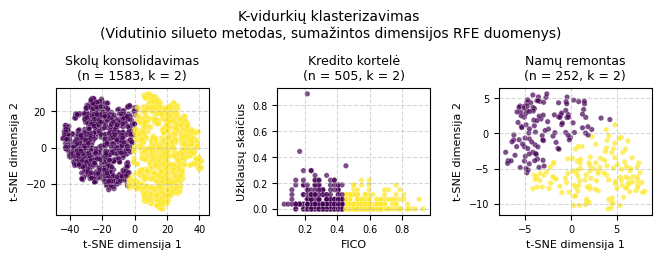

In [37]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.4 

clustering_metrics = []
fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

tsne_data_2_labels = []

for i in range(3):
    kmeans = KMeans(n_clusters=2, random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(tsne_results[i])

    clustering_metrics_fun(tsne_results[i], labels, data_labels[i], clustering_metrics)
    tsne_data_2_labels.append(labels)
    
    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], c=labels, cmap='viridis', alpha=0.7, s=15, edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = 2)', fontsize=9)
    if names[i] == "Kredito kortelė":
        ax.set_xlabel('FICO', fontsize=8)
        ax.set_ylabel('Užklausų skaičius', fontsize=8)
    else:
        ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle( 'K-vidurkių klasterizavimas \n(Vidutinio silueto metodas, sumažintos dimensijos RFE duomenys)',fontsize=10, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig("rfe_tsne_1.png", dpi=300, bbox_inches='tight')

plt.show()

In [38]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            0.86        0.46            1854.22  0.00
1       Kredito kortelė            0.74        0.49             655.47  0.05
2         Namų remontas            0.84        0.46             301.41  0.04


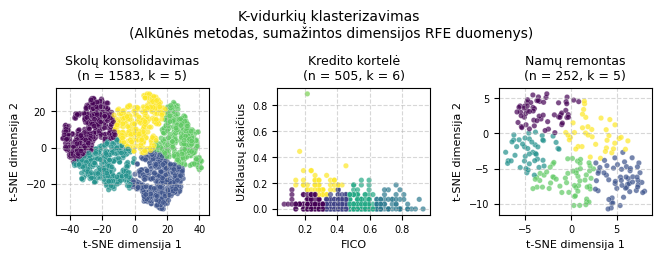

In [39]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.4 

clustering_metrics = []
k = [5, 6, 5]
fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

tsne_data_2_labels = []

for i in range(3):
    kmeans = KMeans(n_clusters=k[i], random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(tsne_results[i])

    clustering_metrics_fun(tsne_results[i], labels, data_labels[i], clustering_metrics)
    tsne_data_2_labels.append(labels)
    
    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], c=labels, cmap='viridis', alpha=0.7, s=15, edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = {k[i]})', fontsize=9)
    if names[i] == "Kredito kortelė":
        ax.set_xlabel('FICO', fontsize=8)
        ax.set_ylabel('Užklausų skaičius', fontsize=8)
    else:
        ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle( 'K-vidurkių klasterizavimas \n(Alkūnės metodas, sumažintos dimensijos RFE duomenys)',fontsize=10, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig("rfe_tsne_2.png", dpi=300, bbox_inches='tight')

plt.show()

In [40]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            0.86        0.39            1754.20  0.02
1       Kredito kortelė            0.70        0.41             571.00  0.09
2         Namų remontas            0.77        0.39             293.54  0.02


## LassoCV

In [41]:
LassoCV_debt_consolidation_data = pd.read_csv('LassoCV_debt_consolidation.csv')
LassoCV_credit_card_data = pd.read_csv('LassoCV_credit_card.csv')
LassoCV_home_improvement_data = pd.read_csv('LassoCV_home_improvement.csv')

In [42]:
datasets = [LassoCV_debt_consolidation_data, LassoCV_credit_card_data, LassoCV_home_improvement_data]
for data in datasets:
    data['credit.policy'] = data['credit.policy'].astype('category')

print(LassoCV_debt_consolidation_data.dtypes)

dti                float64
fico               float64
inq.last.6mths     float64
credit.policy     category
dtype: object


In [43]:
tsne = TSNE(n_components=2, random_state=42, perplexity=50, learning_rate=500, max_iter=2000, early_exaggeration=4)
tsne_LassoCV_debt_consolidation_data = tsne.fit_transform(LassoCV_debt_consolidation_data.select_dtypes(include=[np.number]))
tsne_LassoCV_home_improvement_data = tsne.fit_transform(LassoCV_home_improvement_data.select_dtypes(include=[np.number]))

### Klasterizavimas ant orginalių duomenų

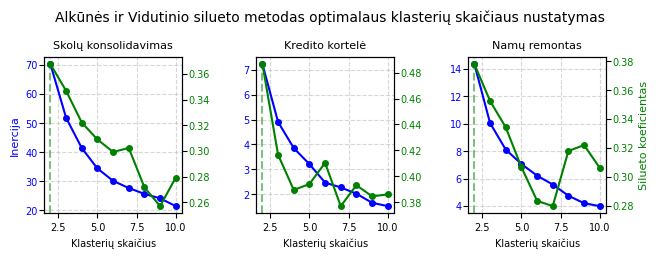

In [44]:
subsets = {
    "Skolų konsolidavimas": LassoCV_debt_consolidation_data.select_dtypes(include=[np.number]),
    "Kredito kortelė": LassoCV_credit_card_data.select_dtypes(include=[np.number]),
    "Namų remontas": LassoCV_home_improvement_data.select_dtypes(include=[np.number])
}

width_inch = 17 / 2.54
height_inch = width_inch * 0.4

fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

for i, (name, data) in enumerate(subsets.items()):
    inertias = []
    all_silhouette_avg = []
    k_range = range(2, 11)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=2026, n_init='auto')
        cluster_labels = kmeans.fit_predict(data)
        
        inertias.append(kmeans.inertia_)
        all_silhouette_avg.append(silhouette_score(data, cluster_labels))

    best_k = k_range[np.argmax(all_silhouette_avg)]

    ax1 = axes[i]
    ax1.plot(k_range, inertias, 'bo-', label='Inertia', markersize=4)
    ax1.set_xlabel('Klasterių skaičius', fontsize=7)
    ax1.tick_params(axis='x', labelsize=7)
    if name == 'Skolų konsolidavimas':
        ax1.set_ylabel('Inercija', color='b', fontsize=8)
    else:
        ax1.set_ylabel('', color='b')
    ax1.tick_params(axis='y', labelsize=7, labelcolor='b', pad=1)
    ax1.set_title(f'{name}', fontsize=8)
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(k_range, all_silhouette_avg, 'go-', label='Siluetas', markersize=4)
    ax2.yaxis.set_major_formatter('{x:.2f}')
    if name == 'Namų remontas':
        ax2.set_ylabel('Silueto koeficientas', color='g', fontsize=8)
    else:
        ax2.set_ylabel('', color='g')
    ax2.tick_params(axis='y', labelsize=7, labelcolor='g', pad=1)
    
    ax2.axvline(x=best_k, color="g", linestyle="--", alpha=0.5)

plt.suptitle('Alkūnės ir Vidutinio silueto metodas optimalaus klasterių skaičiaus nustatymas', fontsize=10, y=0.95)

plt.tight_layout(w_pad=2)
plt.savefig("clusters_5.png", dpi=300, bbox_inches='tight')

plt.show()


In [45]:
names = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]
data_subsets = [
    LassoCV_debt_consolidation_data.select_dtypes(include=[np.number]),
    LassoCV_credit_card_data.select_dtypes(include=[np.number]),
    LassoCV_home_improvement_data.select_dtypes(include=[np.number])
]
data_labels = [
    LassoCV_debt_consolidation_data['credit.policy'],
    LassoCV_credit_card_data['credit.policy'],
    LassoCV_home_improvement_data['credit.policy']
]
tsne_results = [tsne_LassoCV_debt_consolidation_data, LassoCV_credit_card_data.select_dtypes(include=[np.number]).to_numpy(), tsne_LassoCV_home_improvement_data]


--- Skolų konsolidavimas bendra statistika ---
         Kiekis  Procentai (%)
cluster                       
0           846       53.44283
1           737       46.55717

--- Skolų konsolidavimas DAŽNIŲ IR PROCENTŲ LENTELĖ ---
cluster                0             1  Viso
Policy = 0  198 (23.40%)   96 (13.03%)   294
Policy = 1  648 (76.60%)  641 (86.97%)  1289
Viso                 846           737  1583
Išsaugota: clustered_debt_consolidation.csv

--- Kredito kortelė bendra statistika ---
         Kiekis  Procentai (%)
cluster                       
0           268      53.069307
1           237      46.930693

--- Kredito kortelė DAŽNIŲ IR PROCENTŲ LENTELĖ ---
cluster                0             1 Viso
Policy = 0   84 (31.34%)    13 (5.49%)   97
Policy = 1  184 (68.66%)  224 (94.51%)  408
Viso                 268           237  505
Išsaugota: clustered_credit_card.csv

--- Namų remontas bendra statistika ---
         Kiekis  Procentai (%)
cluster                       
0           

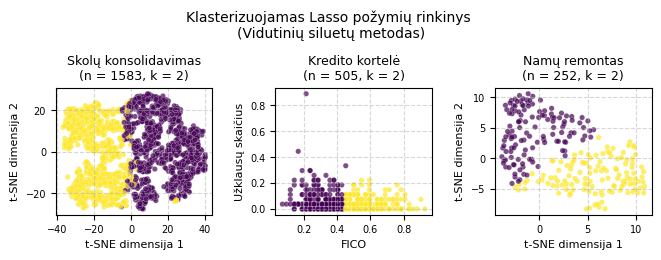

In [46]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.40 

clustering_metrics = []
export_names = ["clustered_debt_consolidation.csv", "clustered_credit_card.csv", "clustered_home_improvement.csv"]

fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

for i in range(3):
    kmeans = KMeans(n_clusters=2, random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(data_subsets[i])

    clustering_metrics_fun(data_subsets[i], labels, data_labels[i], clustering_metrics)


    # -----
    data_subsets[i]['cluster'] = labels
    counts = data_subsets[i]['cluster'].value_counts().sort_index()
    percentages = data_subsets[i]['cluster'].value_counts(normalize=True).sort_index() * 100

    print(f"\n--- {names[i]} bendra statistika ---")
    summary = pd.DataFrame({'Kiekis': counts, 'Procentai (%)': percentages})
    print(summary)

    freq_table = pd.crosstab(data_labels[i], data_subsets[i]['cluster'], margins=True, margins_name="Viso")
    pct_table = pd.crosstab(data_labels[i], data_subsets[i]['cluster'], normalize='columns') * 100

    combined_table = freq_table.astype(str).copy()

    for row in pct_table.index:
        for col in pct_table.columns:
            count = freq_table.loc[row, col]
            pct = pct_table.loc[row, col]
            combined_table.loc[row, col] = f"{count} ({pct:.2f}%)"

    combined_table.index = [f"Policy = {idx}" if idx != "Viso" else "Viso" for idx in combined_table.index]

    print(f"\n--- {names[i]} DAŽNIŲ IR PROCENTŲ LENTELĖ ---")
    print(combined_table)
    # -----


    
    data_subsets[i]['cluster'] = labels
    data_subsets[i].to_csv(export_names[i], index=False)
    print(f"Išsaugota: {export_names[i]}")
    
    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], 
                         c=labels, cmap='viridis', alpha=0.7, s=15, 
                         edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = 2)', fontsize=9)

    if names[i] == "Kredito kortelė":
        ax.set_xlabel('FICO', fontsize=8)
        ax.set_ylabel('Užklausų skaičius', fontsize=8)
    else:
        ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
            
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle('Klasterizuojamas Lasso požymių rinkinys \n(Vidutinių siluetų metodas)', fontsize=10, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig("lasso_original_data_1.png", dpi=300, bbox_inches='tight')

plt.show()

In [47]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            1.06        0.37            1171.64  0.00
1       Kredito kortelė            0.74        0.49             655.47  0.05
2         Namų remontas            1.03        0.38             194.53  0.07


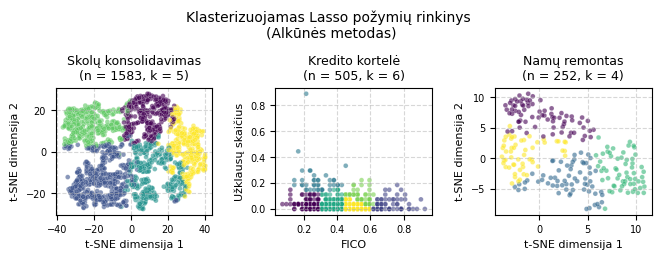

In [48]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.40 

clustering_metrics = []
k = [5, 6, 4]

fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

for i in range(3):
    kmeans = KMeans(n_clusters=k[i], random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(data_subsets[i])

    clustering_metrics_fun(data_subsets[i], labels, data_labels[i], clustering_metrics)
    
    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], 
                         c=labels, cmap='viridis', alpha=0.6, s=12, 
                         edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = {k[i]})', fontsize=9)

    if names[i] == "Kredito kortelė":
        ax.set_xlabel('FICO', fontsize=8)
        ax.set_ylabel('Užklausų skaičius', fontsize=8)
    else:
        ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
            
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle('Klasterizuojamas Lasso požymių rinkinys \n(Alkūnės metodas)', fontsize=10, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig("lasso_original_data_2.png", dpi=300, bbox_inches='tight')

plt.show()

In [49]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            1.04        0.35            5229.66  0.01
1       Kredito kortelė            0.94        0.42            5156.96  0.09
2         Namų remontas            1.13        0.34             745.19  0.04


### Klasterizavimas ant sumažintos dimensijos

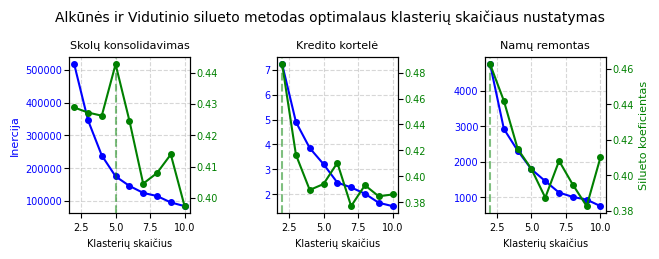

In [50]:
subsets = {
    "Skolų konsolidavimas": tsne_LassoCV_debt_consolidation_data,
    "Kredito kortelė": LassoCV_credit_card_data.select_dtypes(include=[np.number]).to_numpy(),
    "Namų remontas": tsne_LassoCV_home_improvement_data
}

width_inch = 17 / 2.54
height_inch = width_inch * 0.4

fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

for i, (name, data) in enumerate(subsets.items()):
    inertias = []
    all_silhouette_avg = []
    k_range = range(2, 11)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=2026, n_init='auto')
        cluster_labels = kmeans.fit_predict(data)
        
        inertias.append(kmeans.inertia_)
        all_silhouette_avg.append(silhouette_score(data, cluster_labels))

    best_k = k_range[np.argmax(all_silhouette_avg)]

    ax1 = axes[i]
    ax1.plot(k_range, inertias, 'bo-', label='Inertia', markersize=4)
    ax1.set_xlabel('Klasterių skaičius', fontsize=7)
    ax1.tick_params(axis='x', labelsize=7)
    if name == 'Skolų konsolidavimas':
        ax1.set_ylabel('Inercija', color='b', fontsize=8)
    else:
        ax1.set_ylabel('', color='b')
    ax1.tick_params(axis='y', labelsize=7, labelcolor='b', pad=1)
    ax1.set_title(f'{name}', fontsize=8)
    ax1.grid(True, linestyle='--', alpha=0.5)

    ax2 = ax1.twinx()
    ax2.plot(k_range, all_silhouette_avg, 'go-', label='Siluetas', markersize=4)
    ax2.yaxis.set_major_formatter('{x:.2f}')
    if name == 'Namų remontas':
        ax2.set_ylabel('Silueto koeficientas', color='g', fontsize=8)
    else:
        ax2.set_ylabel('', color='g')
    ax2.tick_params(axis='y', labelsize=7, labelcolor='g', pad=1)
    
    ax2.axvline(x=best_k, color="g", linestyle="--", alpha=0.5)

plt.suptitle('Alkūnės ir Vidutinio silueto metodas optimalaus klasterių skaičiaus nustatymas', fontsize=10, y=0.95)

plt.tight_layout(w_pad=2)
plt.savefig("clusters_6.png", dpi=300, bbox_inches='tight')

plt.show()


In [51]:
names = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]
tsne_results = [tsne_LassoCV_debt_consolidation_data, LassoCV_credit_card_data.select_dtypes(include=[np.number]).to_numpy(), tsne_LassoCV_home_improvement_data]


--- Skolų konsolidavimas bendra statistika ---
         Kiekis  Procentai (%)
cluster                       
0           341      21.541377
1           256      16.171826
2           360      22.741630
3           343      21.667720
4           283      17.877448

--- Skolų konsolidavimas DAŽNIŲ IR PROCENTŲ LENTELĖ ---
cluster                0             1             2             3  \
Policy = 0    34 (9.97%)   53 (20.70%)  136 (37.78%)    17 (4.96%)   
Policy = 1  307 (90.03%)  203 (79.30%)  224 (62.22%)  326 (95.04%)   
Viso                 341           256           360           343   

cluster                4  Viso  
Policy = 0   54 (19.08%)   294  
Policy = 1  229 (80.92%)  1289  
Viso                 283  1583  
Išsaugota: clustered_lasso_tsne_debt_consolidation.csv

--- Kredito kortelė bendra statistika ---
         Kiekis  Procentai (%)
cluster                       
0           268      53.069307
1           237      46.930693

--- Kredito kortelė DAŽNIŲ IR PROCENTŲ LEN

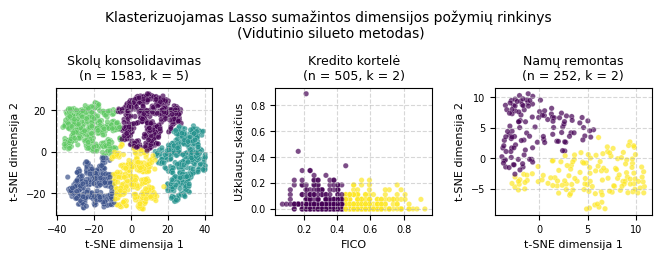

In [52]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.4 

clustering_metrics = []
export_names = ["clustered_lasso_tsne_debt_consolidation.csv", "clustered_lasso_tsne_credit_card.csv", "clustered_lasso_tsne_home_improvement.csv"]
k = [5, 2, 2]
fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

tsne_data_2_labels = []

for i in range(3):
    kmeans = KMeans(n_clusters=k[i], random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(tsne_results[i])

    clustering_metrics_fun(tsne_results[i], labels, data_labels[i], clustering_metrics)
    tsne_data_2_labels.append(labels)


    # -----
    temp_df = pd.DataFrame({'cluster': labels, 'true_label': data_labels[i]})
    
    counts = temp_df['cluster'].value_counts().sort_index()
    percentages = temp_df['cluster'].value_counts(normalize=True).sort_index() * 100

    print(f"\n--- {names[i]} bendra statistika ---")
    summary = pd.DataFrame({'Kiekis': counts, 'Procentai (%)': percentages})
    print(summary)

    freq_table = pd.crosstab(temp_df['true_label'], temp_df['cluster'], margins=True, margins_name="Viso")
    pct_table = pd.crosstab(temp_df['true_label'], temp_df['cluster'], normalize='columns') * 100

    combined_table = freq_table.astype(str).copy()

    for row in pct_table.index:
        for col in pct_table.columns:
            count = freq_table.loc[row, col]
            pct = pct_table.loc[row, col]
            combined_table.loc[row, col] = f"{count} ({pct:.2f}%)"

    combined_table.index = [f"Policy = {idx}" if idx != "Viso" else "Viso" for idx in combined_table.index]
    print(f"\n--- {names[i]} DAŽNIŲ IR PROCENTŲ LENTELĖ ---")
    print(combined_table)
    # -----


    data_subsets[i]['cluster'] = labels
    data_subsets[i].to_csv(export_names[i], index=False)
    print(f"Išsaugota: {export_names[i]}")  

    
    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], c=labels, cmap='viridis', alpha=0.7, s=15, edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = {k[i]})', fontsize=9)
    if names[i] == "Kredito kortelė":
        ax.set_xlabel('FICO', fontsize=8)
        ax.set_ylabel('Užklausų skaičius', fontsize=8)
    else:
        ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle('Klasterizuojamas Lasso sumažintos dimensijos požymių rinkinys \n(Vidutinio silueto metodas)',fontsize=10, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig("lasso_tsne_1.png", dpi=300, bbox_inches='tight')

plt.show()

In [53]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            0.75        0.44            1945.85  0.02
1       Kredito kortelė            0.74        0.49             655.47  0.05
2         Namų remontas            0.84        0.46             305.78  0.04


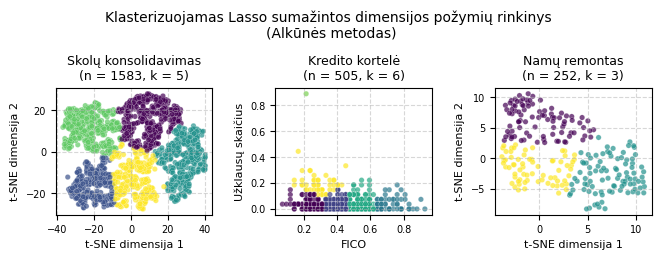

In [54]:
width_inch = 17 / 2.54
height_inch = width_inch * 0.4 

clustering_metrics = []
k = [5, 6, 3]
fig, axes = plt.subplots(1, 3, figsize=(width_inch, height_inch))

tsne_data_2_labels = []

for i in range(3):
    kmeans = KMeans(n_clusters=k[i], random_state=2026, n_init='auto')
    labels = kmeans.fit_predict(tsne_results[i])

    clustering_metrics_fun(tsne_results[i], labels, data_labels[i], clustering_metrics)
    tsne_data_2_labels.append(labels)
    
    ax = axes[i]
    ax.grid(True, linestyle='--', alpha=0.5)
    scatter = ax.scatter(tsne_results[i][:, 0], tsne_results[i][:, 1], c=labels, cmap='viridis', alpha=0.7, s=15, edgecolors='white', linewidth=0.2)
    
    ax.set_title(f'{names[i]}\n(n = {len(data_subsets[i])}, k = {k[i]})', fontsize=9)
    if names[i] == "Kredito kortelė":
        ax.set_xlabel('FICO', fontsize=8)
        ax.set_ylabel('Užklausų skaičius', fontsize=8)
    else:
        ax.set_xlabel('t-SNE dimensija 1', fontsize=8)
        ax.set_ylabel('t-SNE dimensija 2', fontsize=8)
    ax.tick_params(axis='both', labelsize=7)

plt.suptitle('Klasterizuojamas Lasso sumažintos dimensijos požymių rinkinys \n(Alkūnės metodas)',fontsize=10, y=0.95)

plt.tight_layout(pad=1.0)
plt.savefig("lasso_tsne_2.png", dpi=300, bbox_inches='tight')

plt.show()

In [55]:
metrics_df = pd.DataFrame(clustering_metrics)
print(metrics_df)

             Kategorija  Davies-Bouldin  Silhouette  Calinski-Harabasz   ARI
0  Skolų konsolidavimas            0.75        0.44            1945.85  0.02
1       Kredito kortelė            0.70        0.41             571.00  0.09
2         Namų remontas            0.79        0.44             324.73  0.05


## Geriausiam klasterizavimui atliekamas stabilumo testavimas

In [56]:
names = ["Skolų konsolidavimas", "Kredito kortelė", "Namų remontas"]
data_subsets = [
    LassoCV_debt_consolidation_data.select_dtypes(include=[np.number]),
    LassoCV_credit_card_data.select_dtypes(include=[np.number]),
    LassoCV_home_improvement_data.select_dtypes(include=[np.number])
]
data_labels = [
    LassoCV_debt_consolidation_data['credit.policy'],
    LassoCV_credit_card_data['credit.policy'],
    LassoCV_home_improvement_data['credit.policy']
]
tsne_results = [tsne_LassoCV_debt_consolidation_data, LassoCV_credit_card_data.select_dtypes(include=[np.number]).to_numpy(), tsne_LassoCV_home_improvement_data]

In [57]:
for i in range(3):
    print(f"-----{names[i]}-----")
    clustering_stability(50, data_subsets[i], data_labels[i], 2)

-----Skolų konsolidavimas-----
Vidutinis klasterių stabilumas (ARI): 0.948
Stabilumo standartinis nuokrypis: 0.034
Variacijos koeficientas: 0.036
-----Kredito kortelė-----
Vidutinis klasterių stabilumas (ARI): 0.888
Stabilumo standartinis nuokrypis: 0.103
Variacijos koeficientas: 0.116
-----Namų remontas-----
Vidutinis klasterių stabilumas (ARI): 0.850
Stabilumo standartinis nuokrypis: 0.109
Variacijos koeficientas: 0.129
